<center><h1><strong>KNN(K- Nearest Neighbors)</strong></h1></center>

KNN is supervised machine learning algorithm used for:

- Classification
- Regression

It is lazy learning algorithms:

- no model is built during training
- it memorizes the data
- prediction happens at test time

<strong>Intution</strong>

You are in a new city and want to know if a restaurant is good.

You ask your 5 nearest neighbors:

- 4 say "good"
- 1 say "bad"

So you decide -> it is good

That's exactly knn works

<strong>Working process of KNN</strong>

- Step 1: Choose value of K
- Step 2: Calculate distance from new point to all training points
- Step 3: Select K nearest points
- Step 4: Majority voting -> Assign class

Common distance metrics:
- Euclidean Distance
- Manhattan Distance

<strong>Choosing K</strong>

- small K -> Overfitting
- large K -> Underfitting

<strong style="color:red;">Scaling is Important</strong>

Because KNN uses distance.

If one feature is large (e.g. salary in lakhs) and other feature is small (age), distance will be dominated by salary.

Import the necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

Load the dataset

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

Train Test Split the data

In [3]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Scaling the data

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Create the model

In [25]:
knn = KNeighborsClassifier(n_neighbors=9)
model = knn.fit(X_train,y_train)

Prediction

In [26]:
y_pred = knn.predict(X_test)

Evaluation

In [27]:
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix: ",confusion_matrix(y_test,y_pred))
print("Classification Report: ",classification_report(y_test,y_pred))

Accuracy:  0.9649122807017544
Confusion Matrix:  [[41  2]
 [ 2 69]]
Classification Report:                precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



Visualizing K effect

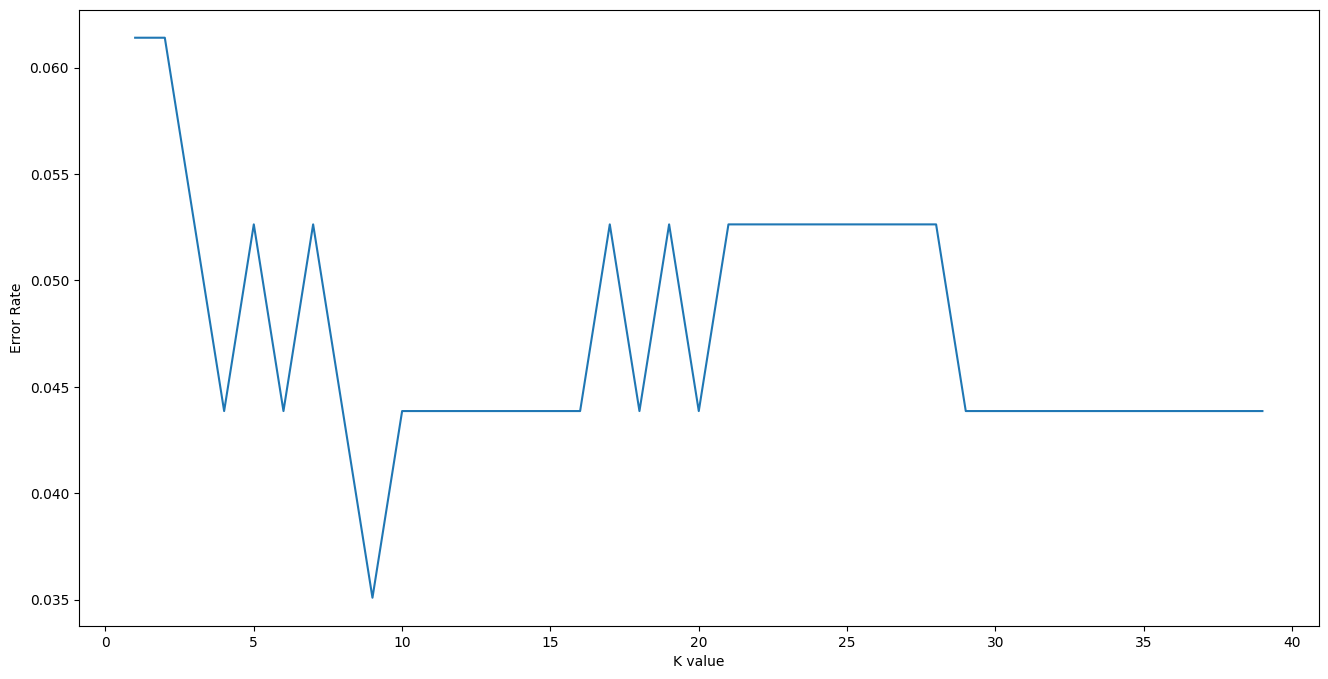

In [8]:
error = []

for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error.append(np.mean(pred_i != y_test))

plt.figure(figsize=(16,8))
plt.plot(range(1,40),error)
plt.xlabel("K value")
plt.ylabel("Error Rate")
plt.show()

<strong>KNN Advantages</strong>

- Simple
- No Training Time
- Works well for small datasets

<strong>Disadvantages</strong>

- Slow for large data
- Sensitive to scaling
- Poor with high dimensional data